## 그림영역(Figure) 과 하위 그래프(Axes)

- Figure : 도화지 전체
- Axes   : 실제 그래프가 그려지는 좌표 영역

하나의 도화지에 여러개의 그래프를 그려내어 비교하여 시각화 할 수 있음.

In [1]:
# 모듈 사용
import matplotlib.pyplot as plt

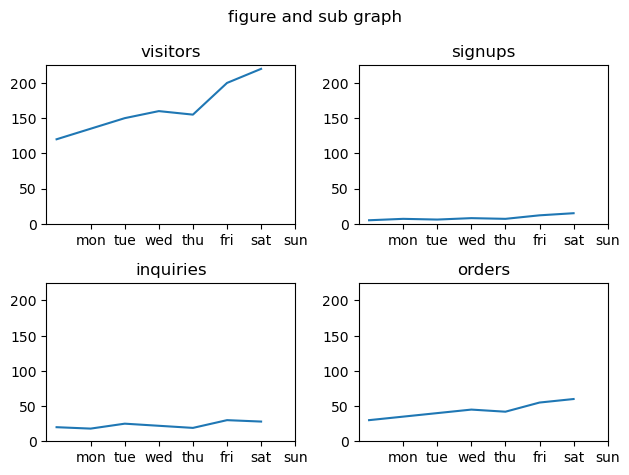

In [11]:
#1. 그림영역 만들기
fig= plt.figure()

#2. 하위 그래프들 추가하기
axes1= fig.add_subplot(2,2, 1) #2행 2열 중 1번째(좌상단)
axes2= fig.add_subplot(2,2, 2) #2행 2열 중 2번째(우상단)
axes3= fig.add_subplot(2,2, 3) #2행 2열 중 3번째(좌하단)
axes4= fig.add_subplot(2,2, 4) #2행 2열 중 4번째(우하단)

#4. 하위 그래프에 데이터 설정.
# [ 배포중인 서비스의 일주일 운영 지표 요약 ]
visitors = [120, 135, 150, 160, 155, 200, 220]   #1) 요일별 방문자 수
signups = [5, 7, 6, 8, 7, 12, 15]                #2) 요일별 회원가입 수
inquiries = [20, 18, 25, 22, 19, 30, 28]         #3) 요일별 문의 건수 (CS 요청)
orders = [30, 35, 40, 45, 42, 55, 60]            #4) 요일별 매출 건수 (주문 수)

axes1.plot(visitors)# 리스트의 index가 x축, y축이 값
axes2.plot(signups)
axes3.plot(inquiries)
axes4.plot(orders)
# x축을 따로 주지 않으면 자동으로 인덱스가 x 값이 됨. (pandas 데이터프레임도 마찬가지)

#5. 하위그래프 제목 표시하기
axes1.set_title('visitors')
axes2.set_title('signups')
axes3.set_title('inquiries')
axes4.set_title('orders')

#6. 하위 그래프의 제목이 겹침. 해결
fig.set_tight_layout(True)

#7. x값을 명시하지 않으면 눈금단위를 matplotlib이 임의로 처리함...
xs=[1,2,3,4,5,6,7]
axes1.set_xticks(xs)
axes2.set_xticks(xs)
axes3.set_xticks(xs)
axes4.set_xticks(xs)

#8. x눈금 단위에 라벨로 함께 표시하기
x_labels= ['mon','tue','wed','thu','fri','sat','sun']
axes1.set_xticklabels(x_labels)
axes2.set_xticklabels(x_labels)
axes3.set_xticklabels(x_labels)
axes4.set_xticklabels(x_labels)

#9. 4개의 하위 그래프 y축 범위가 다르나 보니 각각의 차이가 잘 안보임.
#1) 모든 데이터의 최대값을 구하기
max_value= max( max(visitors), max(signups), max(inquiries), max(orders) )
#2) 모든 하위그래프에 동일한 y축 범위 적용
for ax in [axes1,axes2,axes3,axes4]:
    ax.set_ylim(0, max_value+5)


#10. 그림영역 전체 제목 표시
fig.suptitle('figure and sub graph')

#---------------------------
#3. 그래프 그리기
plt.show()

## 시각화가 필요한 이유
평균, 분산, 상관관계, 회귀선이 모두 같은데(비슷한데).. 산점도로 보면 다른 패턴인 데이터 모양.

#### "통계요약만 보면 같은 데이터처럼 보인지만, 그래프를 그려보면 완전히 다른 이야기를 가진 경우"
통계학자중 앤스컴 코르텟 데이터셋을 만들었음..

In [12]:
# 공통 x 값
x = [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5]

# 데이터셋 1 – 일반적인 선형 관계
y1 = [8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68]

# 데이터셋 2 – 곡선형 관계
y2 = [9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74]

# 데이터셋 3 – 선형 + 이상치
y3 = [7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73]

# 데이터셋 4 – 대부분 동일 + 한 개의 결정적 이상치
y4 = [6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89]

In [13]:
# pandas의 데이터 프레임으로 통계적 수치 확인해보기
import pandas as pd
df= pd.DataFrame({
    'y1': y1,
    'y2': y2,
    'y3': y3,
    'y4': y4
})
df

,y1,y2,y3,y4
0,8.04,9.14,7.46,6.58
1,6.95,8.14,6.77,5.76
2,7.58,8.74,12.74,7.71
3,8.81,8.77,7.11,8.84
4,8.33,9.26,7.81,8.47
5,9.96,8.10,8.84,7.04
6,7.24,6.13,6.08,5.25
7,4.26,3.10,5.39,12.50
8,10.84,9.13,8.15,5.56
9,4.82,7.26,6.42,7.91


In [14]:
# 기술통계를 한번에 쉽게 비교
df.describe()

,y1,y2,y3,y4
count,11.000000,11.000000,11.000000,11.000000
mean,7.500909,7.500909,7.500000,7.500909
std,2.031568,2.031657,2.030424,2.030579
min,4.260000,3.100000,5.390000,5.250000
25%,6.315000,6.695000,6.250000,6.170000
50%,7.580000,8.140000,7.110000,7.040000
75%,8.570000,8.950000,7.980000,8.190000
max,10.840000,9.260000,12.740000,12.500000


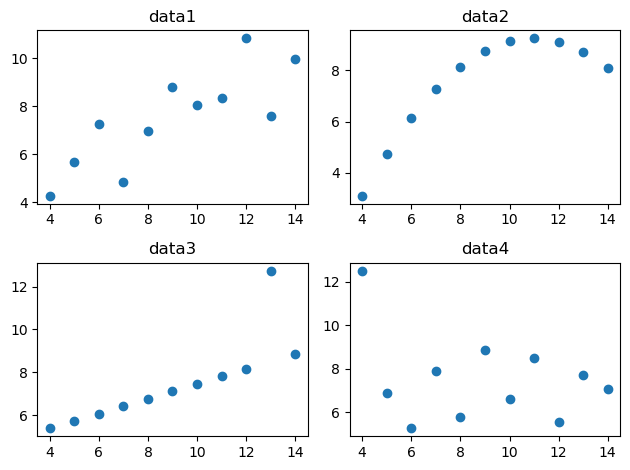

In [15]:
# 값만 보면 평균, 표준편차가 거의 같음.. 같은 특성의 데이터로 보임
# 선형회귀를 그려보면 h(x)=wx+b   [y= 0.5x + 3] .. 회귀계수 coeffient, bias값도 같음

# "통계수치는 같지만 데이터의 분포가 같을까??"
fig= plt.figure()
ax1= fig.add_subplot(2,2,1)
ax2= fig.add_subplot(2,2,2)
ax3= fig.add_subplot(2,2,3)
ax4= fig.add_subplot(2,2,4)

ax1.scatter(x, y1, marker='o')
ax2.scatter(x, y2, marker='o')
ax3.scatter(x, y3, marker='o')
ax4.scatter(x, y4, marker='o')

ax1.set_title('data1')
ax2.set_title('data2')
ax3.set_title('data3')
ax4.set_title('data4')

fig.set_tight_layout(True)
plt.show()

### 그림영역과 서브 그래프를 한번에 만드는 방법 (실무에서 더 많이 사용)
- subplots() : 튜플로 그림영역과 하위그래프들을 모두 만들어 줌.

In [ ]:
fig, axes= plt.subplots(2,2) # 2행 2열

#행열 위치에 따라 값 설정 axes[row, col] 구조
axes[0, 0].plot(vistors)
axes[0, 0].set_title('vistors')

axes[0, 1].plot(signups)
axes[0, 1].set_title('signups')

axes[1, 0].plot(inquiries)
axes[1, 0].set_title('inquiries')

axes[1, 1].plot(orders)
axes[1, 1].set_title('orders')

fig.tight_layout()
plt.show()
